<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%ED%9A%8C%EA%B7%80%ED%8A%B8%EB%A6%AC_260929.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

In [8]:
house = fetch_california_housing()
df = pd.DataFrame(house.data,columns=house.feature_names)
df['target']=house.target

X_data=df.drop('target',axis=1)
y_target=df['target']


In [9]:
rf=RandomForestRegressor(random_state=0,n_estimators=100)
neg_mse_scores=cross_val_score(rf,X_data,y_target,scoring="neg_mean_squared_error",cv=5)
rmse_scores=np.sqrt(-1*neg_mse_scores)
avg_rmse=np.mean(rmse_scores)

print(f"5교차 검증의 개별 Negative MSE scores: {np.round(neg_mse_scores,2)}")
print(f"5교차 검증의 개별 RMSE scores: {np.round(rmse_scores,2)}")
print(f"5교차 검증의 평균 RMSE scores: {np.round(avg_rmse,2)}")

5교차 검증의 개별 Negative MSE scores: [-0.5  -0.35 -0.37 -0.44 -0.47]
5교차 검증의 개별 RMSE scores: [0.71 0.59 0.61 0.66 0.68]
5교차 검증의 평균 RMSE scores: 0.65


In [15]:
def get_model_cv_prediction(model,X_data,y_target):
  neg_mse_scores=cross_val_score(model,X_data,y_target,scoring="neg_mean_squared_error",cv=5)
  rmse_scores=np.sqrt(-1*neg_mse_scores)
  avg_rmse=np.mean(rmse_scores)
  print(f"##### {model.__class__.__name__} #####")
  print(f"5 교차 검증의 평균 RMSE: {avg_rmse:.3f}")

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRFRegressor
from lightgbm import LGBMRegressor

dt_reg=DecisionTreeRegressor(random_state=0,max_depth=4)
gb_reg = GradientBoostingRegressor(random_state=0,n_estimators=1000)
xg_reg=XGBRFRegressor(n_estimators=1000)
lg_reg=LGBMRegressor(n_estimators=1000)

# 트리 기반의 회귀 모델을 반복하면서 평가 수행
models=[rf,dt_reg,gb_reg,xg_reg,lg_reg]
for model in models:
  get_model_cv_prediction(model,X_data,y_target)

##### RandomForestRegressor #####
5 교차 검증의 평균 RMSE: 0.650
##### DecisionTreeRegressor #####
5 교차 검증의 평균 RMSE: 0.809
##### GradientBoostingRegressor #####
5 교차 검증의 평균 RMSE: 0.627
##### XGBRFRegressor #####
5 교차 검증의 평균 RMSE: 0.718
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.164930
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.034871
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.0

<Axes: xlabel='None', ylabel='None'>

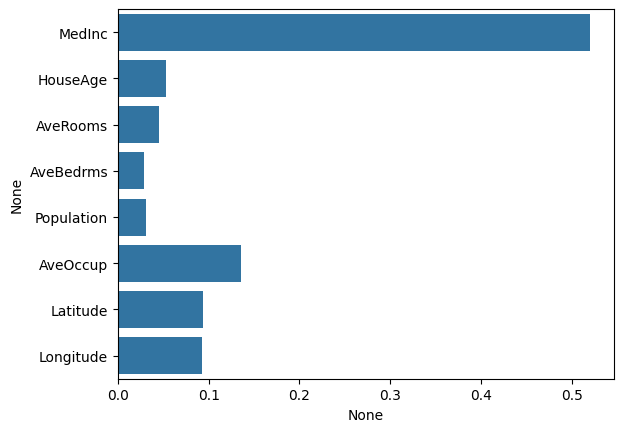

In [23]:
import seaborn as sns

rf_reg=RandomForestRegressor(n_estimators=1000)

rf_reg.fit(X_data,y_target)

feature_series=pd.Series(data=rf_reg.feature_importances_,index=X_data.columns)
feature_series.sort_values(ascending=False)
sns.barplot(x=feature_series,y=feature_series.index)

In [25]:
# 피처 별 상관관계 확인 후 가장 target 데이터와 연관관계가 높은 피처로 회귀 트리 예측선 변화 확인
df.corr()['target'].sort_values(ascending=False)

,target
target,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


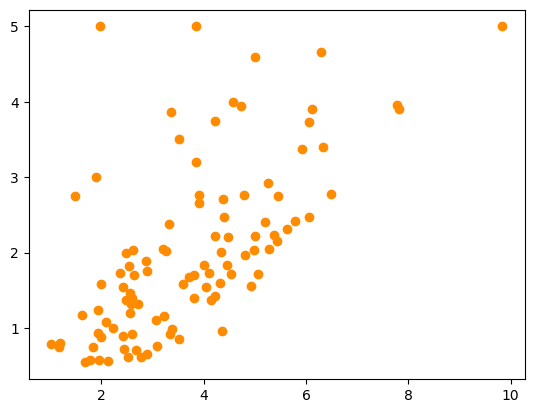

In [29]:
# 샘플 100개만 추출
cali_sample=df[['MedInc','target']]
cali_sample=cali_sample.sample(n=100,random_state=0)
plt.figure()
plt.scatter(cali_sample.MedInc,cali_sample.target,c="darkorange")

In [31]:
from sklearn.linear_model import LinearRegression

# 선형 회귀와 결정 트리 기반의 Regressor 생성
# DecisionTreeRegressor의 max_depth는 각각 2,7
lr_reg = LinearRegression()
lr_reg_2 = DecisionTreeRegressor(max_depth=2)
lr_reg_7 = DecisionTreeRegressor(max_depth=7)

# 실제 예측을 적용할 테스트용 데이터 세트를 4.5~8.5까지의 100개의 데이터 세트로 생성
X_test=np.arange(4.5,8.5,0.04).reshape(-1,1)

# 시각화를 위해 피처만 추출
X_feature=cali_sample['MedInc'].values.reshape(-1,1)
y_target=cali_sample['target'].values.reshape(-1,1)

lr_reg.fit(X_feature,y_target)
lr_reg_2.fit(X_feature,y_target)
lr_reg_7.fit(X_feature,y_target)

pred_lr=lr_reg.predict(X_test)
pred_lr_reg_2=lr_reg_2.predict(X_test)
pred_lr_reg_7=lr_reg_7.predict(X_test)

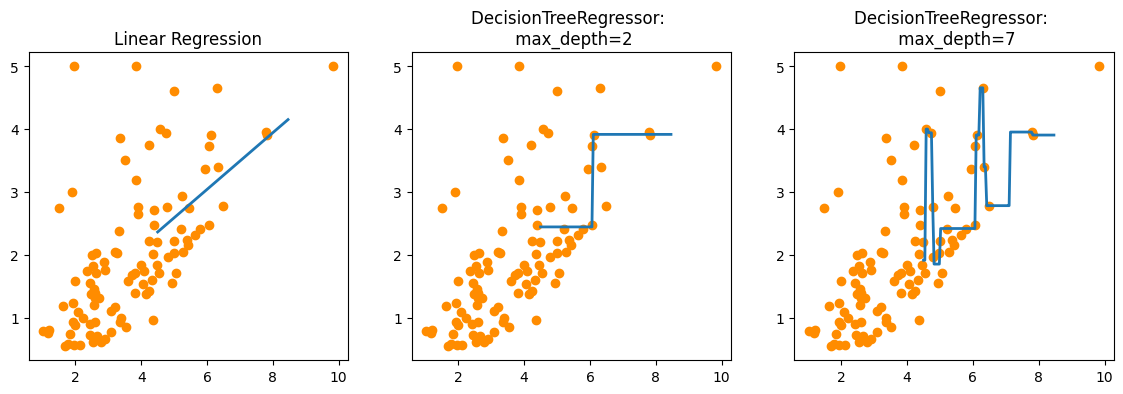

In [33]:
# 회귀선 그리기
fig,(ax1,ax2,ax3)=plt.subplots(figsize=(14,4),ncols=3)

# X축 값을 4.5~8.5로 변환하며 입력했을 때 선형 회귀와 결정 트리 회귀 예측선 시각화
# 선형 회귀로 학습된 모델 회귀 예측선
ax1.set_title('Linear Regression')
ax1.scatter(cali_sample.MedInc,cali_sample.target,c="darkorange")
ax1.plot(X_test,pred_lr, label="linear",linewidth=2)

# DecisionTreeRegressor의 max_depth를 2로 했을 떄 회귀 예측선
ax2.set_title('DecisionTreeRegressor: \n max_depth=2')
ax2.scatter(cali_sample.MedInc,cali_sample.target,c="darkorange")
ax2.plot(X_test,pred_lr_reg_2, label="linear",linewidth=2)

# DecisionTreeRegressor의 max_depth를 7로 했을 떄 회귀 예측선
ax3.set_title('DecisionTreeRegressor: \n max_depth=7')
ax3.scatter(cali_sample.MedInc,cali_sample.target,c="darkorange")
ax3.plot(X_test,pred_lr_reg_7, label="linear",linewidth=2)



선형 회귀는 직선으로 예측 회귀선을 표현하는데 반해, 회귀 트리의 경우 분할되는 데이터 지점에 따라 브랜치를 만들면서 계단 형태로 회귀선을 만듭니다.

DecisionTreeRegressor의 max_depth=7인 경우에는 학습 데이터 세트의 이상치(outlier) 데이터도 학습하면서 복잡한 계단 형태의 회귀선을 만들어 과적합이 되기 쉬운 모델이 되었음을 알 수 있습니다.